In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

In [2]:
# Base case parameters from Yadav et al. (2023), Case B - Mixed Product
# All values sourced from paper Tables 1, S4-S9, Figs. 2-4

FEED_RATE_KG_YR = 240 * 1000 * 330   # 240 TPD, 330 operating days (90% on-stream)
BTX_PROD = 15.5e6                      # kg/yr BTX production (Table 1)
ANNUAL_OPEX = 84e6                     # $/yr total operating expense (Fig. 4b)
COPRODUCT_REVENUE = 82e6               # $/yr all co-products (Fig. 4b)
PAPER_MSP = 1.07                       # $/kg reported BTX MSP (Fig. 4c)

# Back-calculate capital recovery charge for model calibration
# MSP * BTX_PROD = OPEX + Cap_Charge - Coproduct_Rev
CAP_CHARGE = PAPER_MSP * BTX_PROD - ANNUAL_OPEX + COPRODUCT_REVENUE
print(f"Back-calculated capital recovery charge: ${CAP_CHARGE/1e6:.2f}M/yr")

Back-calculated capital recovery charge: $14.59M/yr


In [3]:
# Capital breakdown (Fig. 4a)
TIC = 55.8e6               # Total Installed Capital
TCI = 107e6                 # Total Capital Investment
OLEFIN_SEP_TIC = 10.4e6    # Olefin separation installed capital (20% of TIC)
OTHER_TIC = TIC - OLEFIN_SEP_TIC

# Operating cost breakdown (Fig. 4b)
FEEDSTOCK_COST = 52e6       # $/yr (bales $0.18/kg + flaking $0.42/kg)
TOTAL_UTILITY = 23e6        # $/yr (includes $10M sulfolane solvent)
FIXED_COST = 9e6            # $/yr (labor, overhead)

BASE_RECOVERY = 0.95        # Assumed base-case olefin recovery

# Olefin revenue: ~60% of co-product revenue (estimated from Fig. 4d pie chart)
OLEFIN_REV_FRAC = 0.60
OLEFIN_REVENUE_BASE = OLEFIN_REV_FRAC * COPRODUCT_REVENUE
NON_OLEFIN_REVENUE = (1 - OLEFIN_REV_FRAC) * COPRODUCT_REVENUE

# Olefin mass and implied average price
OLEFIN_MASS = 0.35 * FEED_RATE_KG_YR
AVG_OLEFIN_PRICE = OLEFIN_REVENUE_BASE / (BASE_RECOVERY * OLEFIN_MASS)

# Utility split: ~40% for olefin separation (cryogenic refrigeration)
OLEFIN_UTIL_BASE = 0.40 * TOTAL_UTILITY
NON_OLEFIN_UTIL = TOTAL_UTILITY - OLEFIN_UTIL_BASE

print(f"Olefin mass: {OLEFIN_MASS/1e6:.1f}M kg/yr")
print(f"Implied avg olefin price: ${AVG_OLEFIN_PRICE:.2f}/kg")
print(f"Olefin sep utility: ${OLEFIN_UTIL_BASE/1e6:.1f}M/yr")

Olefin mass: 27.7M kg/yr
Implied avg olefin price: $1.87/kg
Olefin sep utility: $9.2M/yr


In [4]:
# Cost scaling models
# Capital: Seider power-law for cryogenic distillation trains
#   Below 80% recovery: partial condensation (exponent 1.5)
#   Above 80% recovery: full cryogenic train (exponent 2.5)
# OPEX: refrigeration scales with recovery^1.8 (thermodynamic penalty)

def olefin_sep_capital(r):
    if isinstance(r, np.ndarray):
        return np.where(r <= 0.80,
            OLEFIN_SEP_TIC * (r / BASE_RECOVERY)**1.5,
            OLEFIN_SEP_TIC * (r / BASE_RECOVERY)**2.5)
    return OLEFIN_SEP_TIC * (r / BASE_RECOVERY)**(1.5 if r <= 0.80 else 2.5)

def olefin_sep_utility(r):
    return OLEFIN_UTIL_BASE * (r / BASE_RECOVERY)**1.8

def get_tci(r):
    return (OTHER_TIC + olefin_sep_capital(r)) * (TCI / TIC)

def calculate_msp(recovery, price_mult=1.0):
    new_tci = get_tci(recovery)
    new_cap = CAP_CHARGE * (new_tci / TCI)
    new_opex = FEEDSTOCK_COST + NON_OLEFIN_UTIL + olefin_sep_utility(recovery) + FIXED_COST
    olefin_rev = (recovery / BASE_RECOVERY) * OLEFIN_REVENUE_BASE * price_mult
    total_rev = olefin_rev + NON_OLEFIN_REVENUE
    return (new_opex + new_cap - total_rev) / BTX_PROD

In [5]:
# Validate: model should reproduce paper's $1.07/kg at 95% recovery
base_msp = calculate_msp(BASE_RECOVERY, 1.0)
print(f"Model MSP at 95% recovery:  ${base_msp:.2f}/kg")
print(f"Paper reports:               ${PAPER_MSP:.2f}/kg")
print(f"Match: {'VALIDATED' if abs(base_msp - PAPER_MSP) < 0.02 else 'MISMATCH'}")

Model MSP at 95% recovery:  $1.07/kg
Paper reports:               $1.07/kg
Match: VALIDATED


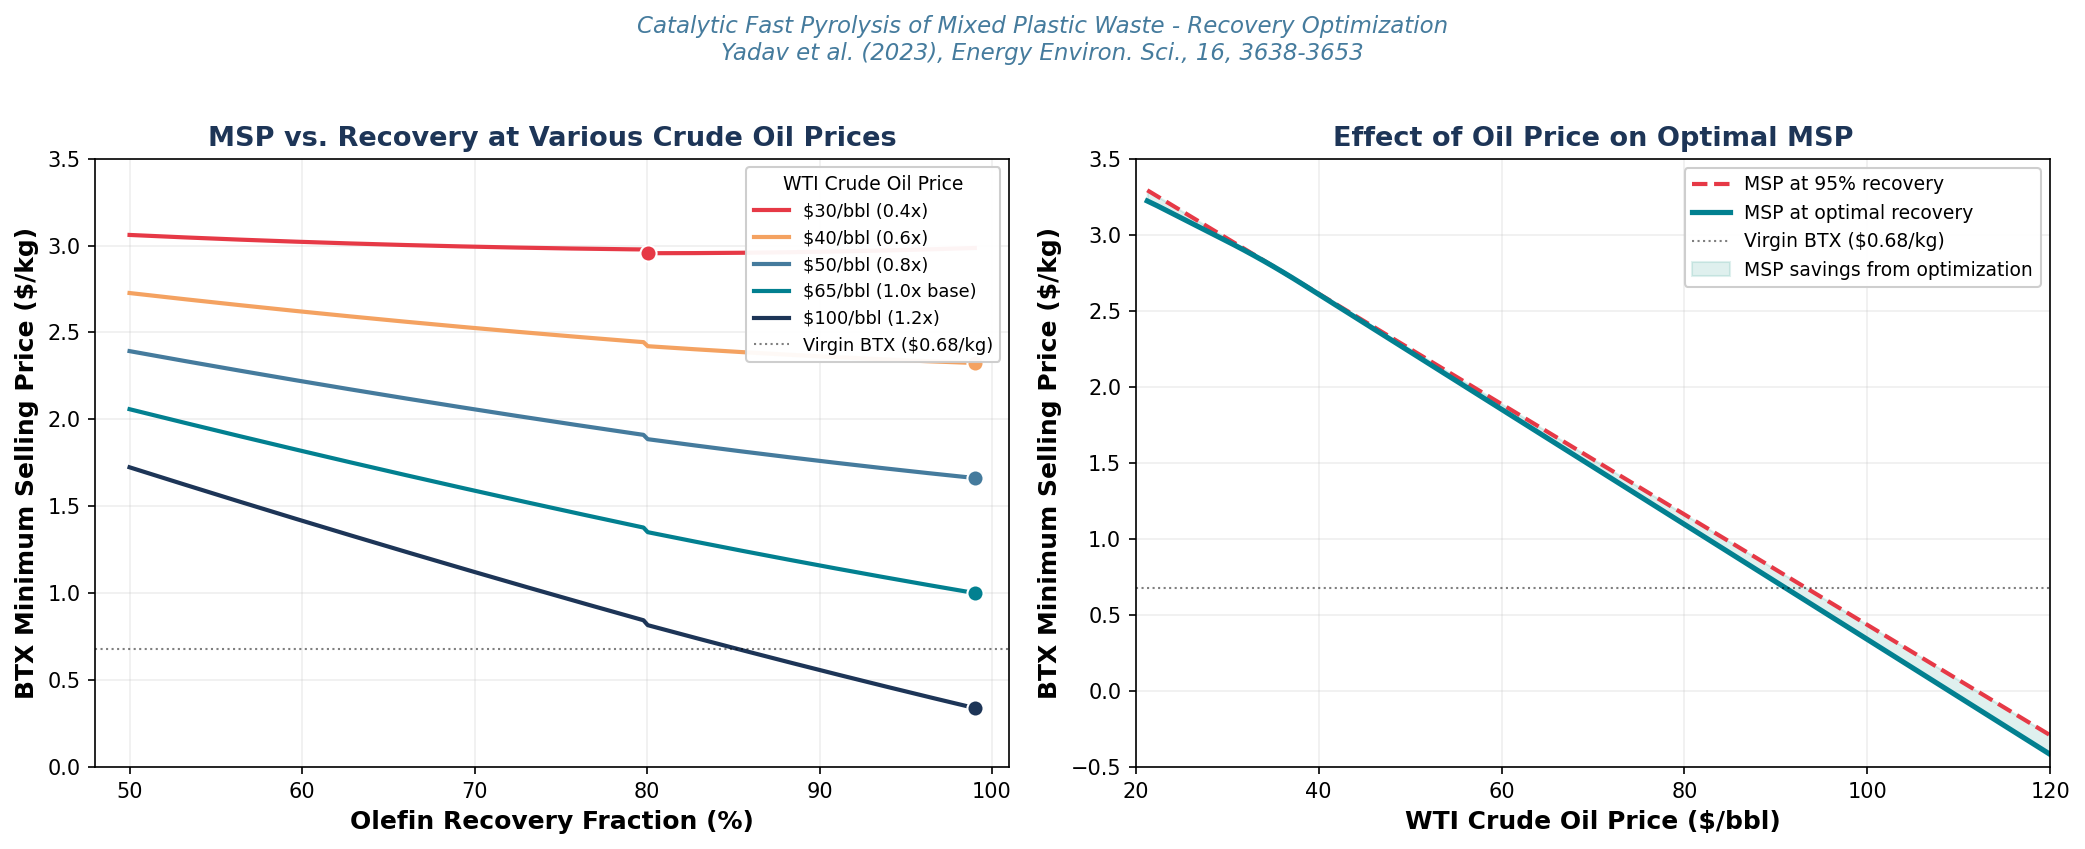

In [6]:
# Sweep recovery 50-99% at five crude oil price scenarios
recovery_range = np.linspace(0.50, 0.99, 200)
price_multipliers = [0.4, 0.6, 0.8, 1.0, 1.2]

TEAL = '#028090'
CORAL = '#E63946'
NAVY = '#1D3557'
GOLD = '#F4A261'
SAGE = '#2A9D8F'
GRAY = '#457B9D'

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plt.subplots_adjust(wspace=0.30)

# Left: MSP curves at different oil prices
ax1 = axes[0]
colors = [CORAL, GOLD, GRAY, TEAL, NAVY]
labels = ['$30/bbl (0.4x)', '$40/bbl (0.6x)', '$50/bbl (0.8x)',
          '$65/bbl (1.0x base)', '$100/bbl (1.2x)']

for pm, c, lab in zip(price_multipliers, colors, labels):
    msps = np.array([calculate_msp(r, pm) for r in recovery_range])
    ax1.plot(recovery_range*100, msps, color=c, linewidth=2, label=lab)
    idx = np.argmin(msps)
    ax1.scatter([recovery_range[idx]*100], [msps[idx]], color=c, s=60,
                zorder=5, edgecolors='white', linewidth=1)

ax1.axhline(y=0.68, color='black', linestyle=':', linewidth=1, alpha=0.5,
            label='Virgin BTX ($0.68/kg)')
ax1.set_xlabel('Olefin Recovery Fraction (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('BTX Minimum Selling Price ($/kg)', fontsize=12, fontweight='bold')
ax1.set_title('MSP vs. Recovery at Various Crude Oil Prices',
              fontsize=13, fontweight='bold', color=NAVY)
ax1.legend(fontsize=8.5, loc='upper right', framealpha=0.95,
           title='WTI Crude Oil Price', title_fontsize=9)
ax1.set_xlim(48, 101)
ax1.set_ylim(0.0, 3.5)
ax1.grid(True, alpha=0.2)

# Right: optimal MSP vs WTI price
ax2 = axes[1]
pm_range = np.linspace(0.3, 1.5, 100)
opt_msps = []
msp_95 = []

for pm in pm_range:
    msps = [calculate_msp(r, pm) for r in recovery_range]
    opt_msps.append(min(msps))
    msp_95.append(calculate_msp(0.95, pm))

opt_msps = np.array(opt_msps)
msp_95 = np.array(msp_95)
wti = 30 + (pm_range - 0.4) * (100 - 30) / (1.2 - 0.4)

ax2.plot(wti, msp_95, color=CORAL, linewidth=2, linestyle='--', label='MSP at 95% recovery')
ax2.plot(wti, opt_msps, color=TEAL, linewidth=2.5, label='MSP at optimal recovery')
ax2.axhline(y=0.68, color='black', linestyle=':', linewidth=1, alpha=0.5,
            label='Virgin BTX ($0.68/kg)')
ax2.fill_between(wti, msp_95, opt_msps, alpha=0.15, color=SAGE,
                 label='MSP savings from optimization')
ax2.set_xlabel('WTI Crude Oil Price ($/bbl)', fontsize=12, fontweight='bold')
ax2.set_ylabel('BTX Minimum Selling Price ($/kg)', fontsize=12, fontweight='bold')
ax2.set_title('Effect of Oil Price on Optimal MSP',
              fontsize=13, fontweight='bold', color=NAVY)
ax2.legend(fontsize=9, loc='upper right', framealpha=0.95)
ax2.set_xlim(20, 120)
ax2.set_ylim(-0.5, 3.5)
ax2.grid(True, alpha=0.2)

plt.suptitle('Catalytic Fast Pyrolysis of Mixed Plastic Waste - Recovery Optimization\n'
             'Yadav et al. (2023), Energy Environ. Sci., 16, 3638-3653',
             fontsize=11, y=1.02, color=GRAY, style='italic')
plt.tight_layout()
plt.show()

In [7]:
# MSP at key recovery fractions
print(f"{'Recovery':<12} {'MSP ($/kg)':<14} {'Olefin Cap ($M)':<18} "
      f"{'Olefin OPEX ($M)':<18} {'Olefin Rev ($M)'}")
print("-" * 75)
for r in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]:
    m = calculate_msp(r)
    cap = olefin_sep_capital(r) / 1e6
    opx = olefin_sep_utility(r) / 1e6
    rev = (r / BASE_RECOVERY) * OLEFIN_REVENUE_BASE / 1e6
    print(f"{r:<12.0%} ${m:<13.2f} ${cap:<17.1f} ${opx:<17.1f} ${rev:<14.1f}")

Recovery     MSP ($/kg)     Olefin Cap ($M)    Olefin OPEX ($M)   Olefin Rev ($M)
---------------------------------------------------------------------------
50%          $2.06          $4.0               $2.9               $25.9          
60%          $1.82          $5.2               $4.0               $31.1          
70%          $1.59          $6.6               $5.3               $36.3          
80%          $1.37          $8.0               $6.8               $41.4          
90%          $1.16          $9.1               $8.3               $46.6          
95%          $1.07          $10.4              $9.2               $49.2          
99%          $1.00          $11.5              $9.9               $51.3          


In [8]:
# Optimal recovery at each oil price scenario
print(f"{'Scenario':<30} {'Opt. Recovery':<15} {'MSP ($/kg)':<12} {'vs 95% Base'}")
print("-" * 70)
for pm, lab in zip([0.4, 0.6, 0.8, 1.0, 1.2],
                    ['Low ($30/bbl)', 'Low-mid ($40/bbl)', 'Mid ($50/bbl)',
                     'Base ($65/bbl)', 'High ($100/bbl)']):
    msps_scan = [calculate_msp(r, pm) for r in recovery_range]
    idx = np.argmin(msps_scan)
    opt_r = recovery_range[idx]
    opt_m = msps_scan[idx]
    base_m = calculate_msp(0.95, pm)
    print(f"{lab:<30} {opt_r:<15.0%} ${opt_m:<11.2f} ${opt_m - base_m:+.2f}")

Scenario                       Opt. Recovery   MSP ($/kg)   vs 95% Base
----------------------------------------------------------------------
Low ($30/bbl)                  80%             $2.96        $-0.02
Low-mid ($40/bbl)              99%             $2.32        $-0.02
Mid ($50/bbl)                  99%             $1.66        $-0.04
Base ($65/bbl)                 99%             $1.00        $-0.07
High ($100/bbl)                99%             $0.34        $-0.10


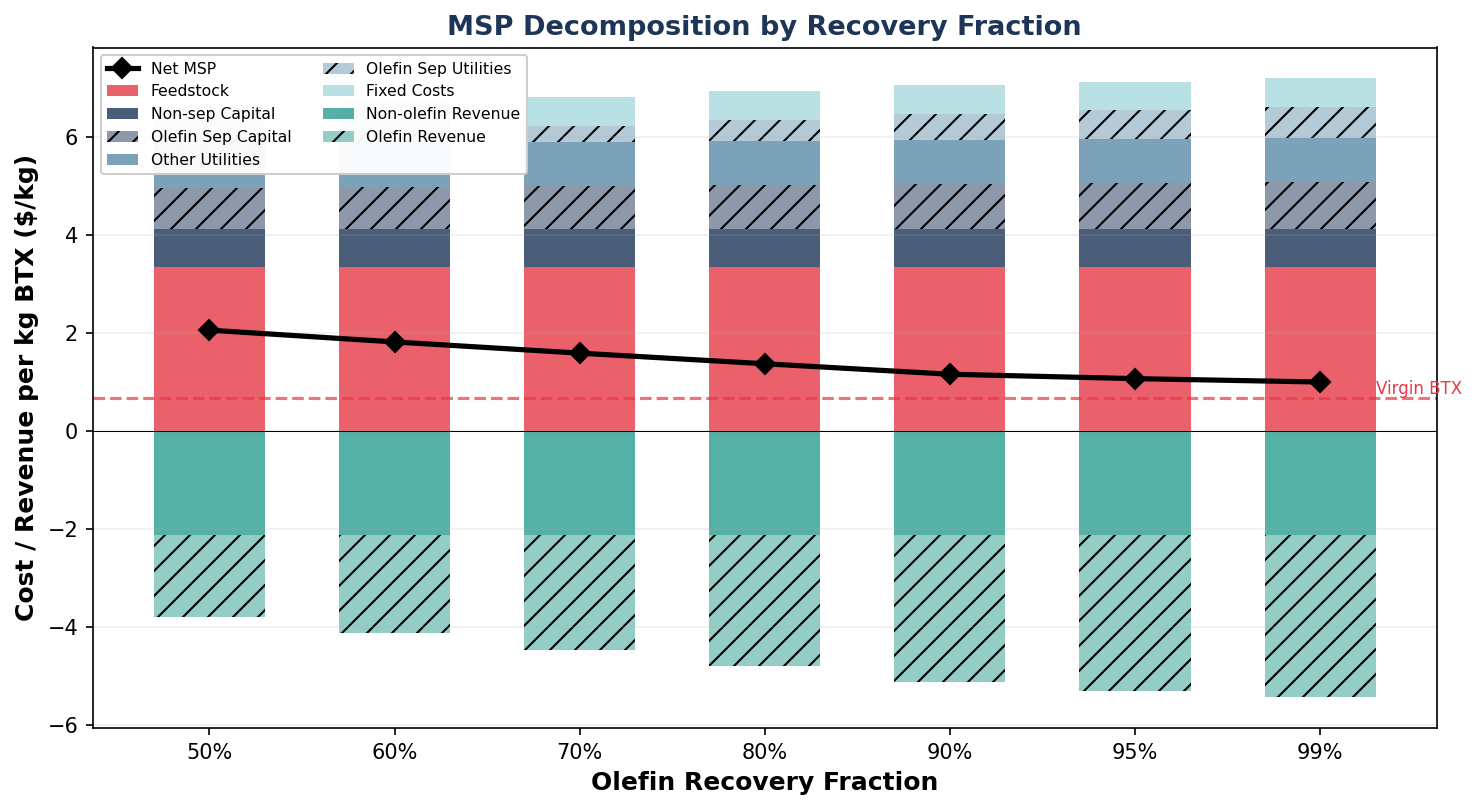

In [9]:
# Stacked bar chart: cost/revenue decomposition by recovery fraction
fig, ax = plt.subplots(figsize=(10, 5.5))

rpts = np.array([0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99])
x_pos = np.arange(len(rpts))
w = 0.6

feedstock_per_kg = FEEDSTOCK_COST / BTX_PROD
fixed_per_kg = FIXED_COST / BTX_PROD
non_olefin_util_per_kg = NON_OLEFIN_UTIL / BTX_PROD
non_olefin_rev_per_kg = NON_OLEFIN_REVENUE / BTX_PROD

olefin_cap_per_kg = np.array([CAP_CHARGE*(get_tci(r)/TCI)/BTX_PROD for r in rpts])
olefin_opex_per_kg = np.array([olefin_sep_utility(r)/BTX_PROD for r in rpts])
other_cap_per_kg = np.array([CAP_CHARGE*(OTHER_TIC*(TCI/TIC)/TCI)/BTX_PROD for _ in rpts])
olefin_rev_per_kg = np.array([(r/BASE_RECOVERY)*OLEFIN_REVENUE_BASE/BTX_PROD for r in rpts])

# Cost bars (positive)
bottom = np.zeros(len(rpts))
ax.bar(x_pos, np.full(len(rpts), feedstock_per_kg), w, bottom=bottom,
       color=CORAL, alpha=0.8, label='Feedstock')
bottom += feedstock_per_kg
ax.bar(x_pos, other_cap_per_kg, w, bottom=bottom,
       color=NAVY, alpha=0.8, label='Non-sep Capital')
bottom += other_cap_per_kg
ax.bar(x_pos, olefin_cap_per_kg, w, bottom=bottom,
       color=NAVY, alpha=0.5, label='Olefin Sep Capital', hatch='//')
bottom += olefin_cap_per_kg
ax.bar(x_pos, np.full(len(rpts), non_olefin_util_per_kg), w, bottom=bottom,
       color=GRAY, alpha=0.7, label='Other Utilities')
bottom += non_olefin_util_per_kg
ax.bar(x_pos, olefin_opex_per_kg, w, bottom=bottom,
       color=GRAY, alpha=0.4, label='Olefin Sep Utilities', hatch='//')
bottom += olefin_opex_per_kg
ax.bar(x_pos, np.full(len(rpts), fixed_per_kg), w, bottom=bottom,
       color='#A8DADC', alpha=0.8, label='Fixed Costs')

# Revenue bars (negative)
ax.bar(x_pos, -np.full(len(rpts), non_olefin_rev_per_kg), w,
       color=SAGE, alpha=0.8, label='Non-olefin Revenue')
ax.bar(x_pos, -olefin_rev_per_kg, w,
       bottom=-np.full(len(rpts), non_olefin_rev_per_kg),
       color=SAGE, alpha=0.5, label='Olefin Revenue', hatch='//')

# Net MSP line
msps = np.array([calculate_msp(r) for r in rpts])
ax.plot(x_pos, msps, color='black', linewidth=2.5, marker='D', markersize=7,
        label='Net MSP', zorder=5)

ax.set_xticks(x_pos)
ax.set_xticklabels([f'{r:.0%}' for r in rpts])
ax.set_xlabel('Olefin Recovery Fraction', fontsize=12, fontweight='bold')
ax.set_ylabel('Cost / Revenue per kg BTX ($/kg)', fontsize=12, fontweight='bold')
ax.set_title('MSP Decomposition by Recovery Fraction',
             fontsize=13, fontweight='bold', color=NAVY)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axhline(y=0.68, color=CORAL, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(6.3, 0.75, 'Virgin BTX', fontsize=8, color=CORAL)
ax.legend(fontsize=7.5, loc='upper left', ncol=2, framealpha=0.95)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

In [10]:
# Three-scenario CAPEX/OPEX comparison
print("=" * 70)
print("CAPEX/OPEX COMPARISON: THREE RECOVERY SCENARIOS")
print("=" * 70)

scenarios = [("Base (95%)", 0.95), ("Low-Oil Opt (80%)", 0.80), ("High-Oil Opt (99%)", 0.99)]

print(f"\n{'Parameter':<35}", end="")
for name, _ in scenarios:
    print(f"{name:<18}", end="")
print("Unit")
print("-" * 90)

rows = [
    ("Olefin Sep. Capital (TIC)",
     lambda r: f"${olefin_sep_capital(r)/1e6:.1f}", "$M"),
    ("Total Capital Investment",
     lambda r: f"${get_tci(r)/1e6:.0f}", "$M"),
    ("Olefin Sep. Utility Cost",
     lambda r: f"${olefin_sep_utility(r)/1e6:.1f}", "$M/yr"),
    ("Olefin Revenue",
     lambda r: f"${(r/BASE_RECOVERY)*OLEFIN_REVENUE_BASE/1e6:.1f}", "$M/yr"),
    ("BTX MSP",
     lambda r: f"${calculate_msp(r):.2f}", "$/kg"),
    ("MSP vs. Virgin BTX ($0.68/kg)",
     lambda r: f"{calculate_msp(r)/0.68:.2f}x", "--"),
]

for label, fn, unit in rows:
    print(f"{label:<35}", end="")
    for _, r in scenarios:
        print(f"{fn(r):<18}", end="")
    print(unit)

CAPEX/OPEX COMPARISON: THREE RECOVERY SCENARIOS

Parameter                          Base (95%)        Low-Oil Opt (80%) High-Oil Opt (99%)Unit
------------------------------------------------------------------------------------------
Olefin Sep. Capital (TIC)          $10.4             $8.0              $11.5             $M
Total Capital Investment           $107              $102              $109              $M
Olefin Sep. Utility Cost           $9.2              $6.8              $9.9              $M/yr
Olefin Revenue                     $49.2             $41.4             $51.3             $M/yr
BTX MSP                            $1.07             $1.37             $1.00             $/kg
MSP vs. Virgin BTX ($0.68/kg)      1.57x             2.02x             1.47x             --


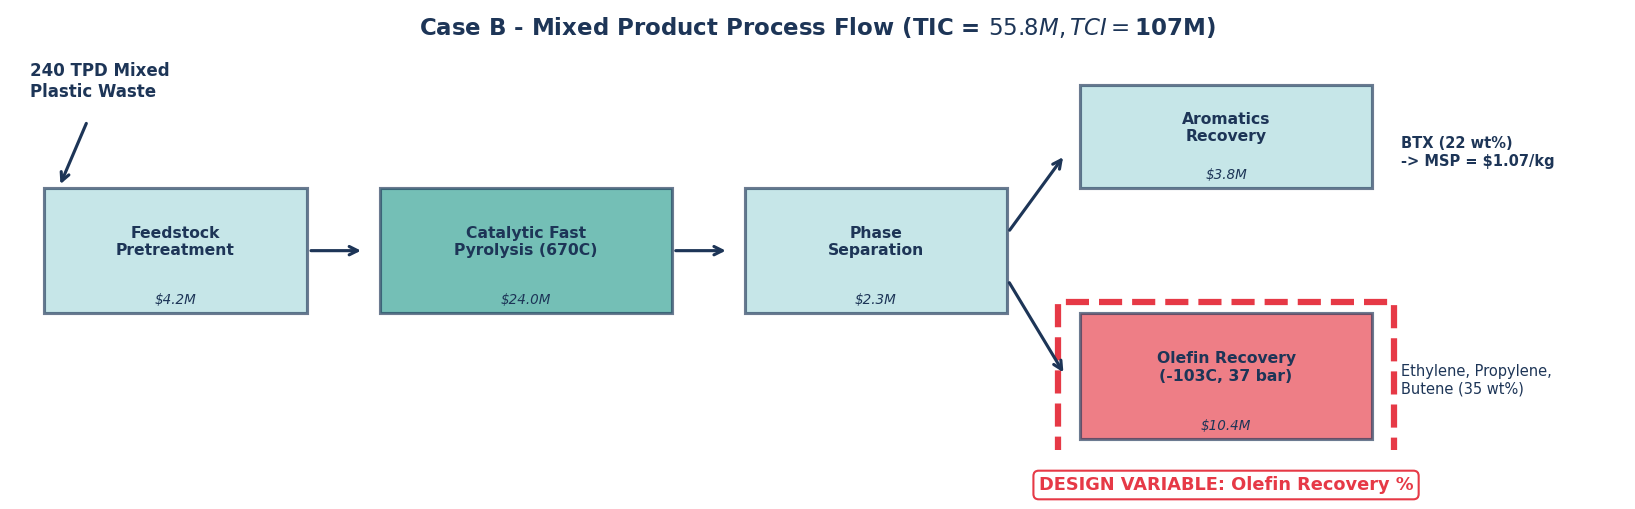

In [11]:
# Simplified process flow diagram
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3.5)
ax.axis('off')

blocks = [
    (0.2, 1.2, 1.8, 1.1, 'Feedstock\nPretreatment', '#A8DADC', '$4.2M'),
    (2.5, 1.2, 2.0, 1.1, 'Catalytic Fast\nPyrolysis (670C)', SAGE, '$24.0M'),
    (5.0, 1.2, 1.8, 1.1, 'Phase\nSeparation', '#A8DADC', '$2.3M'),
    (7.3, 0.1, 2.0, 1.1, 'Olefin Recovery\n(-103C, 37 bar)', CORAL, '$10.4M'),
    (7.3, 2.3, 2.0, 0.9, 'Aromatics\nRecovery', '#A8DADC', '$3.8M'),
]

for x, y, w, h, text, color, cost in blocks:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor=NAVY,
                          linewidth=1.5, alpha=0.65)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2+0.08, text, ha='center', va='center',
            fontsize=7.5, fontweight='bold', color=NAVY)
    ax.text(x+w/2, y+0.12, cost, ha='center', va='center',
            fontsize=6.5, color=NAVY, style='italic')

ap = dict(arrowstyle='->', color=NAVY, lw=1.5)
ax.annotate('', xy=(2.4, 1.75), xytext=(2.0, 1.75), arrowprops=ap)
ax.annotate('', xy=(4.9, 1.75), xytext=(4.5, 1.75), arrowprops=ap)
ax.annotate('', xy=(7.2, 0.65), xytext=(6.8, 1.5), arrowprops=ap)
ax.annotate('', xy=(7.2, 2.6), xytext=(6.8, 1.9), arrowprops=ap)

ax.text(0.1, 3.1, '240 TPD Mixed\nPlastic Waste', fontsize=8,
        color=NAVY, fontweight='bold')
ax.annotate('', xy=(0.3, 2.3), xytext=(0.5, 2.9), arrowprops=ap)
ax.text(9.5, 0.5, 'Ethylene, Propylene,\nButene (35 wt%)', fontsize=7, color=NAVY)
ax.text(9.5, 2.5, 'BTX (22 wt%)\n-> MSP = $1.07/kg', fontsize=7,
        color=NAVY, fontweight='bold')

highlight = plt.Rectangle((7.15, -0.05), 2.3, 1.35, fill=False,
                           edgecolor=CORAL, linewidth=3, linestyle='--')
ax.add_patch(highlight)
ax.text(8.3, -0.35, 'DESIGN VARIABLE: Olefin Recovery %', fontsize=8.5,
        color=CORAL, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=CORAL))

ax.set_title('Case B - Mixed Product Process Flow (TIC = $55.8M, TCI = $107M)',
             fontsize=11, fontweight='bold', color=NAVY, pad=8)
plt.tight_layout()
plt.show()